In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install datasets

INFO: pip is looking at multiple versions of multiprocess to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 471.6/471.6 kB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 15.0 MB/s eta 0:00:00


### **Import Modul**

In [13]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import load_dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader

### **Load Dataset**

In [5]:
# Load dataset dari CSV
train_df = pd.read_csv('/content/drive/MyDrive/Semester 5/Rekayasa Sistem Informasi Cerdas/data/train_data.csv')
test_df = pd.read_csv('/content/drive/MyDrive/Semester 5/Rekayasa Sistem Informasi Cerdas/data/test_data.csv')

In [6]:
LABEL_COLUMNS = ['HS', 'Abusive', 'HS_Individual', 'HS_Group', 'HS_Religion', 'HS_Race',
                 'HS_Physical', 'HS_Gender', 'HS_Other', 'HS_Weak', 'HS_Moderate', 'HS_Strong']

In [7]:
# Menyiapkan tokenizer IndoBERT
tokenizer = AutoTokenizer.from_pretrained('indobenchmark/indobert-base-p1')

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [7]:
# Load dataset ke dalam format Hugging Face
def dataframe_to_dataset(df):
    return {
        'Tweet': df['Tweet'].tolist(),
        'labels': df[LABEL_COLUMNS].values.tolist()
    }

train_dataset = dataframe_to_dataset(train_df)
test_dataset = dataframe_to_dataset(test_df)

In [8]:
tokenizer = AutoTokenizer.from_pretrained("/content/drive/MyDrive/Semester 5/Rekayasa Sistem Informasi Cerdas/indobert-finetuned2")

In [9]:
# Tokenisasi dataset
train_encodings = tokenizer(train_dataset['Tweet'], truncation=True, padding=True, max_length=256)
test_encodings = tokenizer(test_dataset['Tweet'], truncation=True, padding=True, max_length=256)

In [10]:
class MultiLabelDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = MultiLabelDataset(train_encodings, train_dataset['labels'])
test_dataset = MultiLabelDataset(test_encodings, test_dataset['labels'])

### **Fine Tuning Model**



In [11]:
# Load pre-trained IndoBERT model
model = AutoModelForSequenceClassification.from_pretrained('indobenchmark/indobert-base-p1', num_labels=len(LABEL_COLUMNS))

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(50000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [13]:
# Gunakan weighted loss jika dataset tidak seimbang
class WeightedLossBCE(nn.Module):
    def __init__(self, pos_weight=None):
        super(WeightedLossBCE, self).__init__()
        if pos_weight is not None:
            pos_weight = pos_weight.to(device)
        self.bce_loss = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    def forward(self, outputs, labels):
        return self.bce_loss(outputs, labels)

In [14]:
# Hitung pos_weight jika diperlukan
label_counts = train_df[LABEL_COLUMNS].sum(axis=0)
total_count = len(train_df)
pos_weights = torch.tensor((total_count - label_counts) / label_counts)

<ipython-input-14-202ca6db0bc5>:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pos_weights = torch.tensor((total_count - label_counts) / label_counts)


In [15]:
# Gunakan Weighted BCEWithLogitsLoss
loss_fn = WeightedLossBCE(pos_weight=pos_weights)

In [16]:
def compute_metrics(p):
    preds = torch.sigmoid(torch.tensor(p.predictions))
    preds = (preds > 0.5).cpu().numpy()  # Binarize predictions
    labels = torch.tensor(p.label_ids)

    # Gunakan classification_report dari sklearn untuk metrik per label
    report = classification_report(labels, preds, target_names=LABEL_COLUMNS, output_dict=True)

    # Dapatkan nilai rata-rata mikro (global)
    avg_precision = report['micro avg']['precision']
    avg_recall = report['micro avg']['recall']
    avg_f1 = report['micro avg']['f1-score']
    acc = accuracy_score(labels, preds)

    # Metrik per label (dari classification_report)
    metrics_per_label = {
        label: {
            "precision": report[label]['precision'],
            "recall": report[label]['recall'],
            "f1": report[label]['f1-score']
        }
        for label in LABEL_COLUMNS
    }

    # Return metrik global dan per label
    return {
        "accuracy": acc,
        "avg_precision": avg_precision,
        "avg_recall": avg_recall,
        "avg_f1": avg_f1,
        "metrics_per_label": metrics_per_label
    }

In [17]:
# Set TrainingArguments
training_args = TrainingArguments(
    output_dir='./results2',
    num_train_epochs=3,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=2,
    per_device_eval_batch_size=16,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
)

/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [18]:
# Custom Trainer
class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False):
        # inputs = {key: value.to(device) for key, value in inputs.items()}
        labels = inputs.get("labels").to(device)
        outputs = model(**inputs)
        logits = outputs.get("logits")
        loss = loss_fn(logits, labels)

        return (loss, outputs) if return_outputs else loss

# Inisialisasi Trainer
trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

In [19]:
# Fine-tuning
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Avg Precision,Avg Recall,Avg F1,Metrics Per Label
0,0.530800,0.528632,0.425376,0.577157,0.891477,0.700681,"{'HS': {'precision': 0.7962674961119751, 'recall': 0.9118432769367765, 'f1': 0.8501452885014529}, 'Abusive': {'precision': 0.800531914893617, 'recall': 0.9020979020979021, 'f1': 0.8482855800845467}, 'HS_Individual': {'precision': 0.5250596658711217, 'recall': 0.9128630705394191, 'f1': 0.6666666666666666}, 'HS_Group': {'precision': 0.5046875, 'recall': 0.8075, 'f1': 0.6211538461538462}, 'HS_Religion': {'precision': 0.48823529411764705, 'recall': 0.9595375722543352, 'f1': 0.6471734892787524}, 'HS_Race': {'precision': 0.5102880658436214, 'recall': 0.9323308270676691, 'f1': 0.6595744680851063}, 'HS_Physical': {'precision': 0.20833333333333334, 'recall': 0.847457627118644, 'f1': 0.33444816053511706}, 'HS_Gender': {'precision': 0.1893687707641196, 'recall': 0.9344262295081968, 'f1': 0.3149171270718232}, 'HS_Other': {'precision': 0.6684045881126173, 'recall': 0.8638814016172507, 'f1': 0.7536743092298648}, 'HS_Weak': {'precision': 0.5073649754500819, 'recall': 0.9158050221565731, 'f1': 0.6529752501316483}, 'HS_Moderate': {'precision': 0.41358024691358025, 'recall': 0.7952522255192879, 'f1': 0.5441624365482234}, 'HS_Strong': {'precision': 0.3482758620689655, 'recall': 0.926605504587156, 'f1': 0.506265664160401}}"
2,0.136900,0.525290,0.655997,0.744019,0.842362,0.790142,"{'HS': {'precision': 0.8651785714285715, 'recall': 0.8628673196794301, 'f1': 0.8640213999108337}, 'Abusive': {'precision': 0.8911174785100286, 'recall': 0.932067932067932, 'f1': 0.9111328125}, 'HS_Individual': {'precision': 0.7198007471980075, 'recall': 0.7994467496542186, 'f1': 0.7575360419397117}, 'HS_Group': {'precision': 0.6447638603696099, 'recall': 0.785, 'f1': 0.7080045095828635}, 'HS_Religion': {'precision': 0.6515837104072398, 'recall': 0.8323699421965318, 'f1': 0.7309644670050761}, 'HS_Race': {'precision': 0.6804733727810651, 'recall': 0.8646616541353384, 'f1': 0.7615894039735099}, 'HS_Physical': {'precision': 0.4298245614035088, 'recall': 0.8305084745762712, 'f1': 0.5664739884393064}, 'HS_Gender': {'precision': 0.5393258426966292, 'recall': 0.7868852459016393, 'f1': 0.64}, 'HS_Other': {'precision': 0.7545126353790613, 'recall': 0.8450134770889488, 'f1': 0.7972027972027972}, 'HS_Weak': {'precision': 0.6953125, 'recall': 0.7887740029542097, 'f1': 0.7391003460207612}, 'HS_Moderate': {'precision': 0.5369978858350951, 'recall': 0.7537091988130564, 'f1': 0.6271604938271605}, 'HS_Strong': {'precision': 0.6756756756756757, 'recall': 0.9174311926605505, 'f1': 0.7782101167315175}}"


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
Trainer is attempting to log a value of "{'HS': {'

TrainOutput(global_step=1944, training_loss=0.4264181717433066, metrics={'train_runtime': 1479.0302, 'train_samples_per_second': 21.034, 'train_steps_per_second': 1.314, 'total_flos': 4090691720355840.0, 'train_loss': 0.4264181717433066, 'epoch': 2.997686969930609})

### **Save Model & Metric**

In [20]:
trainer.save_model("./indobert-finetuned2")
tokenizer.save_pretrained("./indobert-finetuned2")

('./indobert-finetuned2/tokenizer_config.json',
 './indobert-finetuned2/special_tokens_map.json',
 './indobert-finetuned2/vocab.txt',
 './indobert-finetuned2/added_tokens.json',
 './indobert-finetuned2/tokenizer.json')

In [21]:
import json

# Fungsi untuk menyimpan log history ke file JSON
def save_trainer_history_to_json(trainer, filename="trainer_history.json"):
    history = trainer.state.log_history  # Ambil log history dari trainer

    # Simpan history ke file JSON
    with open(filename, 'w') as file:
        json.dump(history, file, indent=4)

save_trainer_history_to_json(trainer, filename="trainer_history.json")

In [25]:
# Evaluasi model
eval_result = trainer.evaluate()
eval_result

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
Trainer is attempting to log a value of "{'HS': {'

{'eval_loss': 0.4723365902900696,
 'eval_accuracy': 0.584265329733899,
 'eval_avg_precision': 0.6940813629020414,
 'eval_avg_recall': 0.8533766702780787,
 'eval_avg_f1': 0.765530088280554,
 'eval_metrics_per_label': {'HS': {'precision': 0.8709677419354839,
   'recall': 0.8655387355298308,
   'f1': 0.8682447521214828},
  'Abusive': {'precision': 0.88,
   'recall': 0.9230769230769231,
   'f1': 0.9010238907849829},
  'HS_Individual': {'precision': 0.7055288461538461,
   'recall': 0.8118948824343015,
   'f1': 0.754983922829582},
  'HS_Group': {'precision': 0.536115569823435,
   'recall': 0.835,
   'f1': 0.6529814271749755},
  'HS_Religion': {'precision': 0.5302013422818792,
   'recall': 0.9132947976878613,
   'f1': 0.6709129511677282},
  'HS_Race': {'precision': 0.4542124542124542,
   'recall': 0.9323308270676691,
   'f1': 0.6108374384236454},
  'HS_Physical': {'precision': 0.33793103448275863,
   'recall': 0.8305084745762712,
   'f1': 0.4803921568627451},
  'HS_Gender': {'precision': 0.51

In [26]:
import json

# Fungsi untuk menyimpan metrik ke file JSON
def save_metrics_to_json(metrics, filename="metrics.json"):
    with open(filename, 'w') as file:
        json.dump(metrics, file, indent=4)

# Simpan hasil evaluasi ke file JSON
save_metrics_to_json(eval_result, filename="model_metrics2.json")


In [16]:
# Load model yang sudah di-fine-tune
model = AutoModelForSequenceClassification.from_pretrained("/content/drive/MyDrive/Semester 5/Rekayasa Sistem Informasi Cerdas/indobert-finetuned2")

# Pastikan model di device (GPU atau CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
model.eval()

# Buat DataLoader untuk test dataset
test_loader = DataLoader(test_dataset, batch_size=32)

all_preds = []
all_labels = []

# Loop untuk melakukan prediksi pada test data
for batch in test_loader:
    inputs = {key: value.to(device) for key, value in batch.items() if key != 'labels'}
    labels = batch['labels'].to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    # Sigmoid untuk mengubah logit menjadi probabilitas
    preds = torch.sigmoid(outputs.logits).cpu().numpy()
    all_preds.append(preds)
    all_labels.append(labels.cpu().numpy())

# Konversi list ke array numpy
all_preds = np.concatenate(all_preds, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

# Binarisasi prediksi (probabilitas > 0.5 dianggap sebagai prediksi 1)
binarized_preds = (all_preds > 0.5).astype(int)

# LABEL_COLUMNS adalah list yang berisi nama dari 12 label Anda
LABEL_COLUMNS = ['HS', 'Abusive', 'HS_Individual', 'HS_Group', 'HS_Religion',
                 'HS_Race', 'HS_Physical', 'HS_Gender', 'HS_Other',
                 'HS_Weak', 'HS_Moderate', 'HS_Strong']

# Menghitung akurasi per label
accuracy_per_label = {}
for i, label in enumerate(LABEL_COLUMNS):
    true_positives = np.sum((binarized_preds[:, i] == 1) & (all_labels[:, i] == 1))
    true_negatives = np.sum((binarized_preds[:, i] == 0) & (all_labels[:, i] == 0))
    total_samples = all_labels.shape[0]

    # Hitung akurasi per label
    accuracy_per_label[label] = (true_positives + true_negatives) / total_samples

# Tampilkan hasil akurasi per label
for label, acc in accuracy_per_label.items():
    print(f"Accuracy for {label}: {acc:.4f}")

Accuracy for HS: 0.8824
Accuracy for Abusive: 0.9298
Accuracy for HS_Individual: 0.8573
Accuracy for HS_Group: 0.9001
Accuracy for HS_Religion: 0.9591
Accuracy for HS_Race: 0.9722
Accuracy for HS_Physical: 0.9711
Accuracy for HS_Gender: 0.9792
Accuracy for HS_Other: 0.8770
Accuracy for HS_Weak: 0.8546
Accuracy for HS_Moderate: 0.8835
Accuracy for HS_Strong: 0.9780


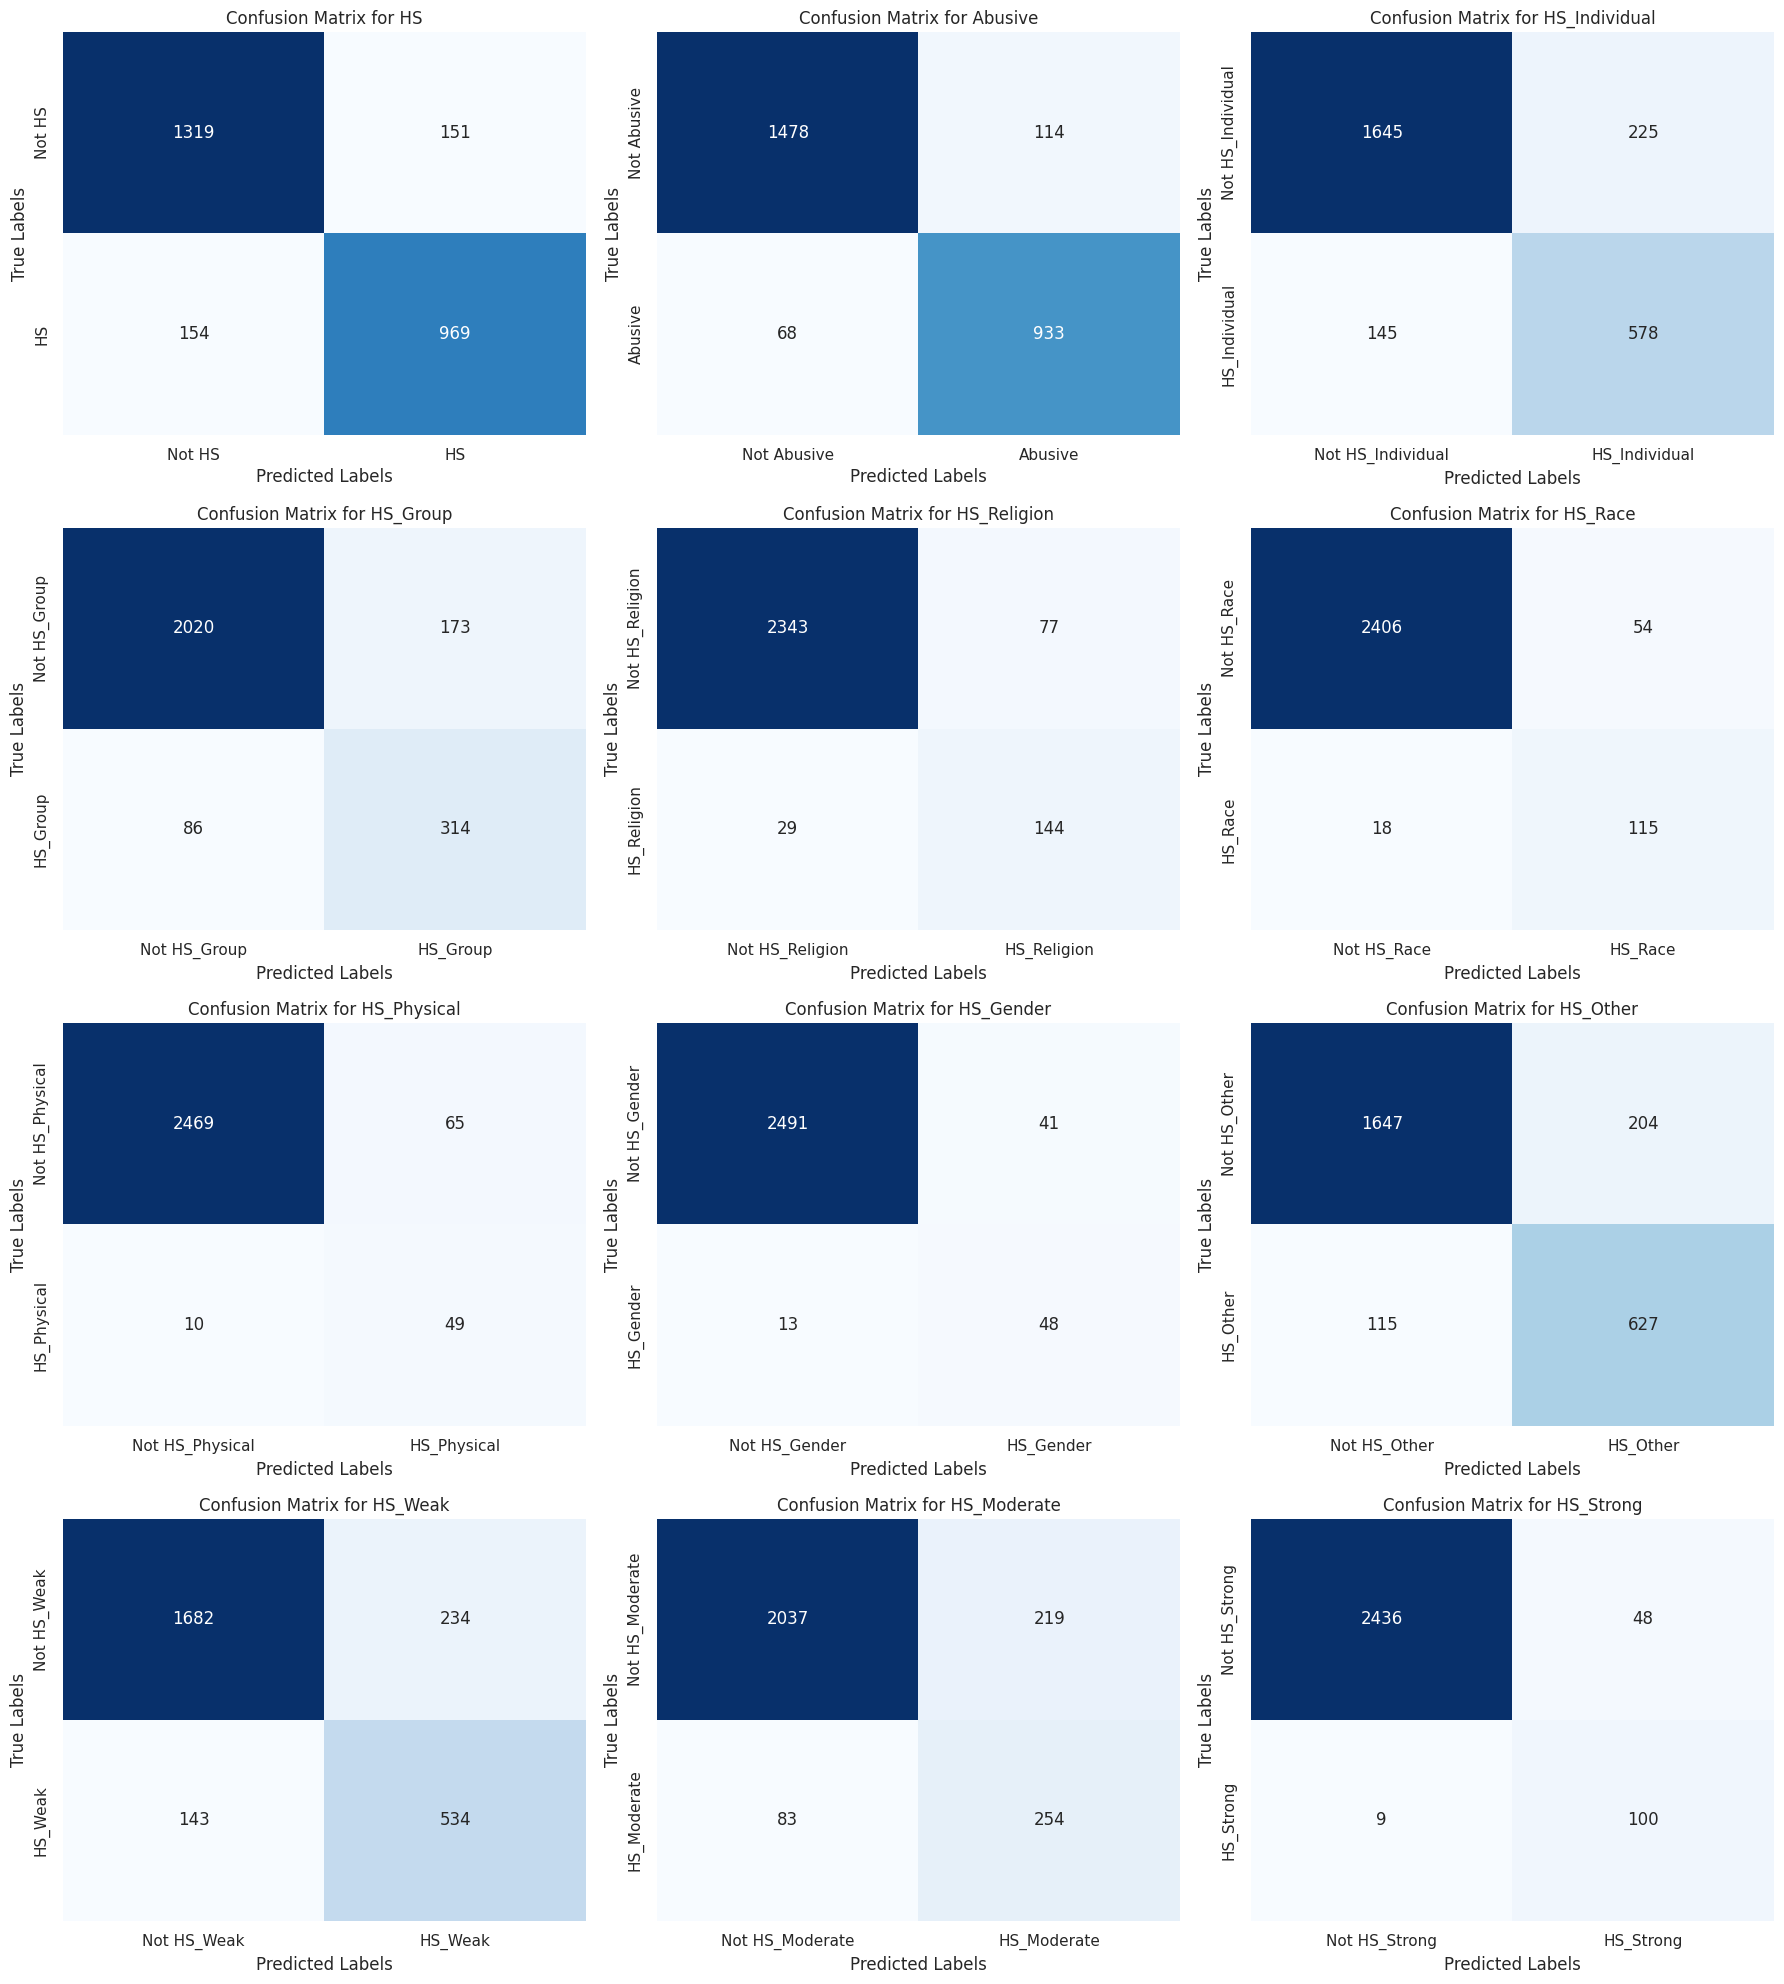

In [26]:
# Mengatur gaya untuk seaborn
sns.set(style='whitegrid')

# Jumlah label
num_labels = len(LABEL_COLUMNS)

# Membuat subplot
fig, axes = plt.subplots(nrows=(num_labels + 2) // 3, ncols=3, figsize=(18, (num_labels + 2) // 3 * 5))
axes = axes.flatten()  # Rata-rata ax untuk memudahkan akses

# Loop untuk menghitung dan memplot confusion matrix untuk setiap label
for i, label in enumerate(LABEL_COLUMNS):
    # Menghitung confusion matrix
    cm = confusion_matrix(all_labels[:, i], binarized_preds[:, i])

    # Menggunakan seaborn heatmap untuk visualisasi
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='Blues', cbar=False,
                xticklabels=['Not '+label, label], yticklabels=['Not '+label, label])
    axes[i].set_title(f'Confusion Matrix for {label}')
    axes[i].set_xlabel('Predicted Labels')
    axes[i].set_ylabel('True Labels')

# Menyembunyikan axes yang tidak digunakan
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [20]:
# Hitung classification report
report = classification_report(all_labels, binarized_preds, target_names=LABEL_COLUMNS, output_dict=True)

# Mengumpulkan metrik
accuracy_per_label = {}
for i, label in enumerate(LABEL_COLUMNS):
    true_positives = np.sum((binarized_preds[:, i] == 1) & (all_labels[:, i] == 1))
    true_negatives = np.sum((binarized_preds[:, i] == 0) & (all_labels[:, i] == 0))
    total_samples = all_labels.shape[0]

    # Hitung akurasi per label
    accuracy_per_label[label] = (true_positives + true_negatives) / total_samples

# Menyiapkan DataFrame untuk visualisasi
metrics_df = pd.DataFrame({
    'Label': LABEL_COLUMNS,
    'Accuracy': [accuracy_per_label[label] for label in LABEL_COLUMNS],
    'Precision': [report[label]['precision'] for label in LABEL_COLUMNS],
    'Recall': [report[label]['recall'] for label in LABEL_COLUMNS],
    'F1 Score': [report[label]['f1-score'] for label in LABEL_COLUMNS]
})

# Set Label sebagai index
metrics_df.set_index('Label', inplace=True)

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


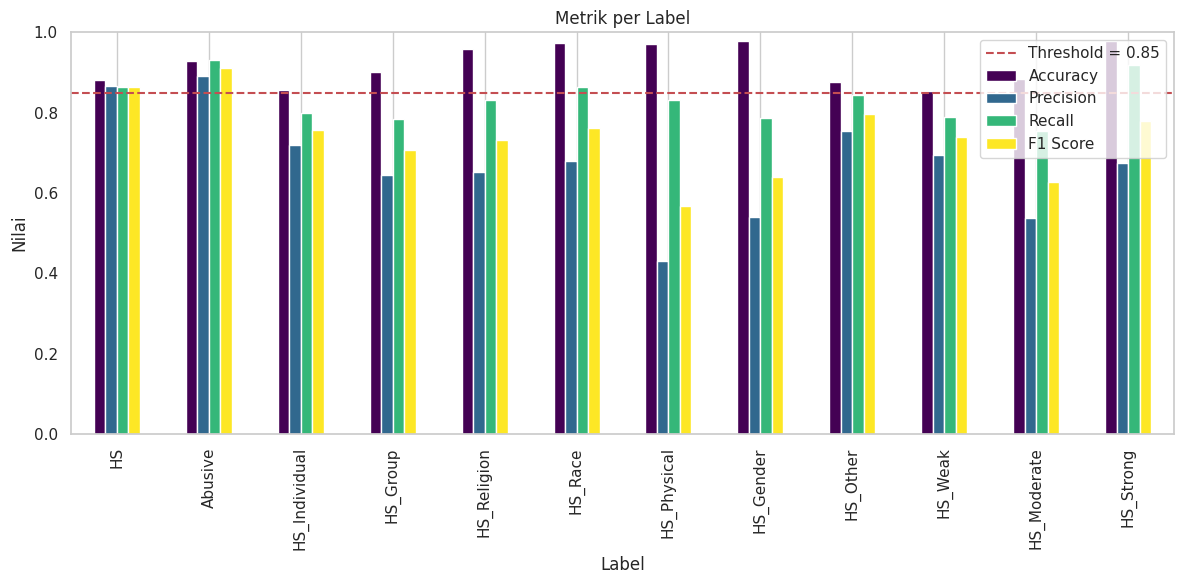

In [23]:
# Visualisasi Metrik
metrics_df.plot(kind='bar', figsize=(12, 6), colormap='viridis')
plt.title('Metrik per Label')
plt.ylabel('Nilai')
plt.ylim(0, 1)  # Rentang metrik dari 0 hingga 1
plt.grid(axis='y')

# Menambahkan garis horizontal pada nilai 0.85
plt.axhline(y=0.85, color='r', linestyle='--', label='Threshold = 0.85')

# Menambahkan legenda
plt.legend()

# Tampilkan plot
plt.tight_layout()
plt.show()